# COLO829 telomere restructuring 


In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.backends.backend_pdf import PdfPages
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

## 1. Inputs



In [2]:
BASE = 'your/base/dir' # replace with your path

TECHS = {
    'PB': {
        'BL': os.path.join(BASE, 'COLO829-BL_pb.telo.center.txt.clean.gz'),
        'T':  os.path.join(BASE, 'COLO829-T_pb.telo.center.txt.clean.gz'),
    },
    'UL-ONT-R10': {
        'BL': os.path.join(BASE, 'COLO829-BL_UL-ONT-R10.all.sorted.tagged.telo.center.txt.clean.gz'),
        'T':  os.path.join(BASE, 'COLO829-T-PassageB_UL-ONT-R10.all.sorted.tagged.telo.center.txt.clean.gz'),
    },
}

# ---- shared parameters ----
MAX_SIZE         = 15_000   # bp into telomere to consider for the signal track + plots
MIN_DEPTH        = 3        # at a position, require >= this many reads to compute fraction
SITE_MIN_READS   = 3       # skip ends with fewer reads than this
MIN_NON_CANON_BP = 0        # ignore non-canonical runs shorter than this (0 = include all)
ROLLING_W        = 25       # smoothing window (bp) for the restructuring detector
BOUND_CUTOFF     = 0.3     # score threshold for left/right bound calls
BUFFER_BP        = 100      # min distance between left and right bounds to call a span
OUT_DIR          = BASE

## 2. Load `ft center` TSVs


In [3]:
FT_CENTER_COLS = [
    'chrom', 'centering_position', 'strand', 'subset_sequence',
    'reference_start', 'reference_end', 'query_name', 'RG', 'HP',
    'centered_query_start', 'centered_query_end', 'query_length',
    'query_sequence',
]

def read_ft_center(path):
    df = pd.read_csv(
        path, sep='\t', header=None, skiprows=1,
        usecols=list(range(13)), names=FT_CENTER_COLS,
    )
    for c in ('centering_position', 'centered_query_start', 'centered_query_end'):
        df[c] = df[c].astype(int)
    return df

tsvs = {}
for tech, samples in TECHS.items():
    for sample, path in samples.items():
        key = (tech, sample)
        print(f'Loading {key} <- {os.path.basename(path)}')
        tsvs[key] = read_ft_center(path)
        n = tsvs[key]
        print(f'  {len(n)} rows, {n["query_name"].nunique()} molecules, '
              f'{n.groupby(["chrom", "centering_position"]).ngroups} ends')

Loading ('PB', 'BL') <- COLO829-BL_pb.telo.center.txt.clean.gz


FileNotFoundError: [Errno 2] No such file or directory: 'your/base/dir/COLO829-BL_pb.telo.center.txt.clean.gz'

## 3. Per-position non-canonical fraction


In [17]:
_motif_pat_cache = {}
def _motif_indices(seq_lower, motif):
    pat = _motif_pat_cache.setdefault(motif, re.compile(re.escape(motif)))
    return np.fromiter((m.start() for m in pat.finditer(seq_lower)), dtype=int)

def noncanonical_fraction_per_end(
    tsv,
    max_size=MAX_SIZE,
    motif_plus='ccctaa',
    motif_minus='ttaggg',
    min_non_canon_bp=MIN_NON_CANON_BP,
    min_depth=MIN_DEPTH,
    site_min_reads=SITE_MIN_READS,
    include_leading_trailing=False,
    trim_to_coverage=True,
):
    out = {}
    grouped = (
        tsv.assign(span=tsv['centered_query_end'])
           .sort_values('span')
           .groupby(['chrom', 'centering_position'])
    )
    for (chrom, pos), group in grouped:
        if len(group) < site_min_reads:
            continue
        depth = np.zeros(max_size, dtype=np.int32)
        noncanon = np.zeros(max_size, dtype=np.int32)

        for row in group.itertuples():
            seq = getattr(row, 'query_sequence')
            qe  = int(getattr(row, 'centered_query_end'))
            if not isinstance(seq, str) or qe < 1:
                continue
            sub = seq[-qe:].lower()
            L = min(len(sub), max_size)
            if L <= 0:
                continue
            depth[:L] += 1

            plus_idx  = _motif_indices(sub, motif_plus)
            minus_idx = _motif_indices(sub, motif_minus)
            idx = plus_idx if len(plus_idx) >= len(minus_idx) else minus_idx
            if idx.size == 0:
                if include_leading_trailing:
                    noncanon[:L] += 1
                continue

            diffs = np.diff(idx)
            mask = diffs > 6
            if mask.any():
                starts = (idx[:-1][mask] + 6).astype(int)
                sizes  = (diffs[mask] - 6).astype(int)
                keep = sizes >= min_non_canon_bp
                for st, sz in zip(starts[keep], sizes[keep]):
                    if st >= L or sz <= 0:
                        continue
                    noncanon[st:min(st + sz, L)] += 1

            if include_leading_trailing:
                first_start = int(idx[0])
                if first_start > 0:
                    noncanon[:min(first_start, L)] += 1
                tail_start = int(idx[-1]) + 6
                if tail_start < L:
                    noncanon[tail_start:L] += 1

        valid = depth >= min_depth
        if not valid.any():
            continue
        last_idx = (np.where(valid)[0].max() + 1) if trim_to_coverage else max_size
        frac = np.full(last_idx, np.nan)
        d = depth[:last_idx]; n = noncanon[:last_idx]
        ok = d >= min_depth
        frac[ok] = n[ok] / d[ok]
        out[(chrom, pos)] = frac
    return out

# build signal track for each (tech, sample)
noncanon = {}
for key, df in tsvs.items():
    print(f'Signal track for {key} ...')
    noncanon[key] = noncanonical_fraction_per_end(df)
    print(f'  {len(noncanon[key])} ends with track')

Signal track for ('PB', 'BL') ...
  76 ends with track
Signal track for ('PB', 'T') ...
  64 ends with track
Signal track for ('UL-ONT-R10', 'BL') ...
  76 ends with track
Signal track for ('UL-ONT-R10', 'T') ...
  66 ends with track


## 4. Restructuring detection


In [18]:
def _rolling_avg(x, w):
    return np.convolve(x, np.ones(w) / w, mode='same')

def _first_idx_ge(arr, cutoff):
    idx = np.flatnonzero(arr >= cutoff)
    return int(idx[0]) if idx.size else None

def _last_idx_ge(arr, cutoff, end=None):
    if end is not None and end > 0:
        arr = arr[:end]
    idx = np.flatnonzero(arr >= cutoff)
    return int(idx[-1]) if idx.size else None

def _end_mol_counts(tsv):
    return tsv.groupby(['chrom', 'centering_position']).size()

def restructuring_per_tech(noncanon_bl, noncanon_t, bl_counts, t_counts,
                           rolling_w=ROLLING_W, cutoff=BOUND_CUTOFF,
                           buffer=BUFFER_BP, drop_keys=None):
    # For every end present in BOTH samples of a technology, compute left/right bounds.
    # Returns a DataFrame, one row per shared end, with per-end molecule counts.
    drop = set(drop_keys or [])
    shared = set(noncanon_bl) & set(noncanon_t)
    rows = []
    for k in sorted(shared):
        if k in drop:
            continue
        bl_raw = noncanon_bl[k]
        t_raw  = noncanon_t[k]
        bl = _rolling_avg(np.nan_to_num(bl_raw, nan=0.0), rolling_w)
        t  = _rolling_avg(np.nan_to_num(t_raw,  nan=0.0), rolling_w)
        L = min(len(bl), len(t))
        bl = bl[:L]; t = t[:L]

        right_bounds = bl * -(t - bl)
        left_bounds  = bl * (1 - np.abs(t - bl))

        right_most = _first_idx_ge(right_bounds, cutoff)
        end_for_left = right_most if (right_most is not None and right_most > buffer) else None
        left_most = _last_idx_ge(left_bounds, cutoff, end=end_for_left) if right_most is not None else None

        spans = (left_most is not None) and (right_most is not None) and (right_most - left_most >= buffer)

        rows.append({
            'chrom': k[0],
            'centering_position': int(k[1]),
            'left_bound_bp':  left_most,
            'right_bound_bp': right_most,
            'restructured_span_bp': (right_most - left_most) if spans else None,
            'is_restructured': bool(spans),
            'n_bl_mols': int(bl_counts.get(k, 0)),
            'n_t_mols':  int(t_counts.get(k, 0)),
            'track_len_bp': int(L),
        })
    return pd.DataFrame(rows).sort_values(['chrom', 'centering_position']).reset_index(drop=True)

restruct = {}
for tech in TECHS:
    bl_c = _end_mol_counts(tsvs[(tech, 'BL')])
    t_c  = _end_mol_counts(tsvs[(tech, 'T')])
    restruct[tech] = restructuring_per_tech(
        noncanon[(tech, 'BL')], noncanon[(tech, 'T')], bl_c, t_c,
    )
    n = len(restruct[tech])
    r = restruct[tech]['is_restructured'].sum()
    print(f'{tech}: {r}/{n} ends restructured ({r/n:.1%})' if n else f'{tech}: 0 shared ends')

restruct['PB'].head()

PB: 9/64 ends restructured (14.1%)
UL-ONT-R10: 9/66 ends restructured (13.6%)


,chrom,centering_position,left_bound_bp,right_bound_bp,restructured_span_bp,is_restructured,n_bl_mols,n_t_mols,track_len_bp
0,haplotype1-0000001,95162752,NaN,NaN,NaN,False,20,39,3589
1,haplotype1-0000002,3070,1149.0,2000.0,851.0,True,26,24,4228
2,haplotype1-0000003,3510,NaN,NaN,NaN,False,55,57,3730
3,haplotype1-0000003,146990123,NaN,NaN,NaN,False,29,61,2962
4,haplotype1-0000004,6362,3371.0,4180.0,809.0,True,28,35,6134


## 5. Combine technologies

In [19]:
merged = None
for tech, df in restruct.items():
    d = df.copy()
    d = d.rename(columns={c: f'{c}_{tech}' for c in d.columns
                          if c not in ('chrom', 'centering_position')})
    merged = d if merged is None else merged.merge(d, on=['chrom', 'centering_position'], how='outer')

# both-platform restructured
tech_cols = [f'is_restructured_{t}' for t in TECHS]
for c in tech_cols:
    if c in merged.columns:
        merged[c] = merged[c].fillna(False)
merged['restructured_all_platforms'] = merged[tech_cols].all(axis=1) if all(c in merged.columns for c in tech_cols) else False
merged['restructured_any_platform']  = merged[tech_cols].any(axis=1) if all(c in merged.columns for c in tech_cols) else False

merged = merged.sort_values(['chrom', 'centering_position']).reset_index(drop=True)

# headline counts
n_total = len(merged)
for tech in TECHS:
    col = f'is_restructured_{tech}'
    if col in merged.columns:
        n = int(merged[col].sum())
        print(f'{tech:<11} restructured: {n}/{n_total} = {n/n_total:.1%}' if n_total else f'{tech}: 0')
n_both = int(merged['restructured_all_platforms'].sum())
n_any  = int(merged['restructured_any_platform'].sum())
if n_total:
    print(f'BOTH PLATFORMS: {n_both}/{n_total} = {n_both/n_total:.1%}')
    print(f'ANY  PLATFORM : {n_any}/{n_total} = {n_any/n_total:.1%}')

# union set used downstream (Sections 8/9)
restructured_in_any = set(
    zip(merged.loc[merged['restructured_any_platform'], 'chrom'],
        merged.loc[merged['restructured_any_platform'], 'centering_position'].astype(int))
)
print(f'\nrestructured_in_any: {len(restructured_in_any)} ends')

merged.head(15)

PB          restructured: 9/66 = 13.6%
UL-ONT-R10  restructured: 9/66 = 13.6%
BOTH PLATFORMS: 6/66 = 9.1%
ANY  PLATFORM : 12/66 = 18.2%

restructured_in_any: 12 ends


,chrom,centering_position,left_bound_bp_PB,right_bound_bp_PB,restructured_span_bp_PB,is_restructured_PB,n_bl_mols_PB,n_t_mols_PB,track_len_bp_PB,left_bound_bp_UL-ONT-R10,right_bound_bp_UL-ONT-R10,restructured_span_bp_UL-ONT-R10,is_restructured_UL-ONT-R10,n_bl_mols_UL-ONT-R10,n_t_mols_UL-ONT-R10,track_len_bp_UL-ONT-R10,restructured_all_platforms,restructured_any_platform
0,haplotype1-0000001,95162752,NaN,NaN,NaN,False,20.0,39.0,3589.0,NaN,NaN,NaN,False,20,19,4887,False,False
1,haplotype1-0000002,3070,1149.0,2000.0,851.0,True,26.0,24.0,4228.0,1148.0,2002.0,854.0,True,7,12,4367,True,True
2,haplotype1-0000003,3510,NaN,NaN,NaN,False,55.0,57.0,3730.0,NaN,NaN,NaN,False,14,19,4621,False,False
3,haplotype1-0000003,146990123,NaN,NaN,NaN,False,29.0,61.0,2962.0,NaN,NaN,NaN,False,18,24,4227,False,False
4,haplotype1-0000004,6362,3371.0,4180.0,809.0,True,28.0,35.0,6134.0,3375.0,4198.0,823.0,True,11,15,6895,True,True
5,haplotype1-0000004,135163267,NaN,NaN,NaN,False,34.0,46.0,3289.0,NaN,NaN,NaN,False,18,19,5206,False,False
6,haplotype1-0000005,44327944,1819.0,1826.0,NaN,False,11.0,26.0,4902.0,1862.0,1863.0,NaN,False,19,18,7857,False,False
7,haplotype1-0000006,61912483,385.0,505.0,120.0,True,29.0,56.0,4321.0,NaN,469.0,NaN,False,3,11,1998,False,True
8,haplotype1-0000007,3999,812.0,813.0,NaN,False,28.0,25.0,5171.0,582.0,805.0,223.0,True,8,19,5014,False,True
9,haplotype1-0000010,2163,NaN,NaN,NaN,False,46.0,52.0,3569.0,NaN,NaN,NaN,False,8,13,3323,False,False


In [20]:
# ends called as restructured in BOTH platforms
both_ends = merged.loc[merged['restructured_all_platforms'],
                       ['chrom', 'centering_position',
                        'left_bound_bp_PB',  'right_bound_bp_PB',
                        'left_bound_bp_UL-ONT-R10', 'right_bound_bp_UL-ONT-R10']]
print(f'Both-platform restructured ends: {len(both_ends)}')
both_ends

Both-platform restructured ends: 6


,chrom,centering_position,left_bound_bp_PB,right_bound_bp_PB,left_bound_bp_UL-ONT-R10,right_bound_bp_UL-ONT-R10
1,haplotype1-0000002,3070,1149.0,2000.0,1148.0,2002.0
4,haplotype1-0000004,6362,3371.0,4180.0,3375.0,4198.0
16,haplotype1-0000014,4366,712.0,1533.0,707.0,1532.0
38,haplotype2-0000048,84346615,371.0,1767.0,368.0,1773.0
45,haplotype2-0000054,3999,373.0,806.0,3277.0,3378.0
46,haplotype2-0000055,8877,964.0,1912.0,1336.0,1902.0


## 6. Per-end plots (BL on top, T on bottom)


In [8]:
def _plot_one_sample(tsv, chrom, center_pos, ax,
                    max_size=MAX_SIZE, title_prefix='', ylim=60,
                    left_bound=None, right_bound=None):
    group = (
        tsv.loc[(tsv['chrom'] == chrom) & (tsv['centering_position'] == int(center_pos))]
           .assign(span=lambda d: d['centered_query_end'])
           .sort_values('span')
    )
    n = len(group)
    for i, row in enumerate(group.itertuples(index=False)):
        seq = getattr(row, 'query_sequence', None)
        qe  = int(getattr(row, 'centered_query_end', 0))
        if not isinstance(seq, str) or qe < 1:
            continue
        sub = seq[-qe:].lower()
        plus_idx  = _motif_indices(sub, 'ccctaa')
        minus_idx = _motif_indices(sub, 'ttaggg')
        idx = plus_idx if len(plus_idx) >= len(minus_idx) else minus_idx

        if len(sub) >= 6:
            ax.add_patch(Rectangle((0, i - 0.4), len(sub) - 6, 0.8,
                                   color='deepskyblue', linewidth=0))

        if idx.size > 1:
            diffs = np.diff(idx)
            mask = diffs > 6
            starts = idx[:-1][mask] + 6
            sizes  = diffs[mask] - 6
            for st, sz in zip(starts, sizes):
                if sz <= 0:
                    continue
                ax.add_patch(Rectangle((int(st), i - 0.4), int(sz), 0.8,
                                       color='red', linewidth=0))

    for b, c in [(left_bound, 'dimgray'), (right_bound, 'black')]:
        if b is not None:
            ax.axvline(b, color=c, lw=0.8, ls='--', alpha=0.8)

    ax.set_xlim(0, max_size)
    ax.set_ylim(-2, max(ylim, n + 2))
    ax.set_title(f'{title_prefix}{chrom}:{center_pos} (n={n})', fontsize=9)
    ax.set_ylabel('Molecule')
    ax.set_xticks(range(0, max_size + 1, 2000))


def plot_paired_for_tech(tech, restruct_df, only_restructured=False,
                        out_pdf=None, max_size=MAX_SIZE, figsize=(12, 7)):
    tsv_bl = tsvs[(tech, 'BL')]
    tsv_t  = tsvs[(tech, 'T')]
    df = restruct_df.copy()
    if only_restructured:
        df = df[df['is_restructured']]
    pdf = PdfPages(out_pdf) if out_pdf else None
    for _, r in df.iterrows():
        chrom, pos = r['chrom'], int(r['centering_position'])
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize, sharex=True)
        fig.subplots_adjust(hspace=0.35)
        _plot_one_sample(tsv_bl, chrom, pos, ax1, max_size=max_size,
                         title_prefix=f'[{tech}] BL — ',
                         left_bound=r['left_bound_bp'], right_bound=r['right_bound_bp'])
        _plot_one_sample(tsv_t, chrom, pos, ax2, max_size=max_size,
                         title_prefix=f'[{tech}] T  — ',
                         left_bound=r['left_bound_bp'], right_bound=r['right_bound_bp'])
        ax2.set_xlabel('Position into telomere (bp)')
        if pdf:
            pdf.savefig(fig, dpi=200)
            plt.close(fig)
        else:
            plt.show()
    if pdf:
        pdf.close()
        print(f'wrote {out_pdf} ({len(df)} ends)')

In [4]:
for tech, df in restruct.items():
    suffix = tech.lower().replace('-', '_')
    out_pdf = os.path.join(OUT_DIR, f'telomere_paired_all_{suffix}.pdf')
    plot_paired_for_tech(tech, df, only_restructured=False, out_pdf=out_pdf)

NameError: name 'restruct' is not defined

In [5]:
for tech, df in restruct.items():
    suffix = tech.lower().replace('-', '_')
    out_pdf = os.path.join(OUT_DIR, f'telomere_paired_restructured_{suffix}.pdf')
    plot_paired_for_tech(tech, df, only_restructured=True, out_pdf=out_pdf)

NameError: name 'restruct' is not defined

## 7. Save tables

In [6]:
for tech, df in restruct.items():
    suffix = tech.lower().replace('-', '_')
    out = os.path.join(OUT_DIR, f'telomere_restructuring_{suffix}.csv')
    df.to_csv(out, index=False)
    print(f'wrote {out} ({len(df)} ends)')

merged_out = os.path.join(OUT_DIR, 'telomere_restructuring_merged.csv')
merged.to_csv(merged_out, index=False)
print(f'wrote {merged_out} ({len(merged)} ends)')

NameError: name 'restruct' is not defined

## 8. Restructuring length distributions


In [7]:
import seaborn as sns

MIN_MOLS = 5   # require >= this many telomeric molecules in BOTH BL and T (per tech)

def _median_telo_len(tsv, chrom, pos):
    s = tsv.loc[(tsv['chrom'] == chrom) & (tsv['centering_position'] == int(pos)),
                'centered_query_end']
    return float(s.median()) if len(s) else np.nan

# inclusion rule: an end is plotted/measured for tech X if it is called restructured
# in AT LEAST ONE technology (union), AND it has >= MIN_MOLS in BOTH BL and T of tech X,
# AND tech X has detector bounds for it (i.e., tech X's left_bound_bp is defined).
rows = []
dropped = []
for tech in TECHS:
    df_idx = restruct[tech].set_index(['chrom', 'centering_position'])
    for (chrom, pos) in sorted(restructured_in_any):
        if (chrom, pos) not in df_idx.index:
            dropped.append((tech, chrom, pos, 'end_not_in_tech', None, None))
            continue
        r = df_idx.loc[(chrom, pos)]
        n_bl = int(r['n_bl_mols'])
        n_t  = int(r['n_t_mols'])
        if n_bl < MIN_MOLS or n_t < MIN_MOLS:
            dropped.append((tech, chrom, pos, 'low_coverage', n_bl, n_t))
            continue
        if pd.isnull(r['left_bound_bp']):
            dropped.append((tech, chrom, pos, 'no_tech_bound', n_bl, n_t))
            continue

        lb = float(r['left_bound_bp'])
        rb = float(r['right_bound_bp'])
        bl_med = _median_telo_len(tsvs[(tech, 'BL')], chrom, pos)
        t_med  = _median_telo_len(tsvs[(tech, 'T')],  chrom, pos)
        rows.append({
            'technology': tech,
            'chrom': chrom,
            'centering_position': pos,
            'left_bound_bp': lb,
            'right_bound_bp': rb,
            'bl_median_end_bp': bl_med,
            't_median_end_bp': t_med,
            'n_bl_mols': n_bl,
            'n_t_mols':  n_t,
            'length_at_last_shared_tvr_bp': lb,
            'bl_shortening_bp':            bl_med - lb,
            't_restructured_length_bp':    t_med  - lb,
        })

restructured_lengths = pd.DataFrame(rows)

print(f'Inclusion: restructured in ANY tech, >= {MIN_MOLS} mols in both BL & T, bounds defined.')
print('ends per technology BEFORE negative-metric filter:')
print(restructured_lengths.groupby('technology').size())

# A negative metric means the inferred breakpoint sits past the median telomere length —
# almost always a detector artifact at the edge of read coverage. Drop & report.
neg_mask = ((restructured_lengths['t_restructured_length_bp'] < 0) |
            (restructured_lengths['bl_shortening_bp'] < 0))
if neg_mask.any():
    print(f'\nDropping {int(neg_mask.sum())} end(s) with negative metric (detector edge artifact):')
    print(restructured_lengths.loc[neg_mask,
        ['technology', 'chrom', 'centering_position',
         'left_bound_bp', 'right_bound_bp',
         'bl_median_end_bp', 't_median_end_bp',
         'bl_shortening_bp', 't_restructured_length_bp']].to_string(index=False))
    restructured_lengths = restructured_lengths.loc[~neg_mask].reset_index(drop=True)

print('\nends per technology FINAL:')
print(restructured_lengths.groupby('technology').size())

if dropped:
    dd = pd.DataFrame(dropped, columns=['tech', 'chrom', 'pos', 'reason', 'n_bl', 'n_t'])
    print('\nPre-metric drops (union ends excluded from each tech):')
    print(dd.groupby(['tech', 'reason']).size().to_string())

restructured_lengths.head()

NameError: name 'restruct' is not defined

NameError: name 'restructured_lengths' is not defined

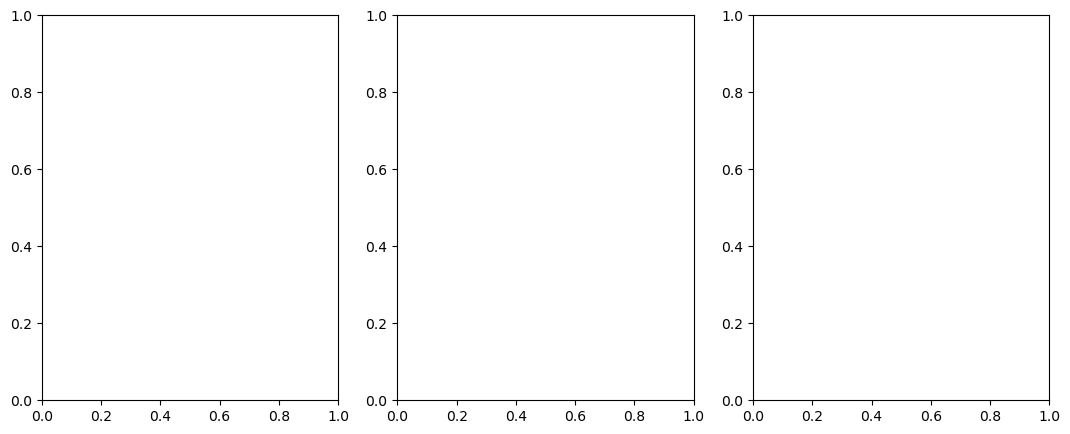

In [8]:
metric_specs = [
    ('length_at_last_shared_tvr_bp', 'Length at last shared TVR (bp)'),
    ('bl_shortening_bp',            'BL telomere length past last shared TVR\n(BL median − last shared TVR, bp)'),
    ('t_restructured_length_bp',    'T residual past last shared TVR\n(T median − last shared TVR, bp)'),
]

tech_order = list(TECHS.keys())
palette = {'PB': '#4c72b0', 'UL-ONT-R10': '#dd8452'}

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
for ax, (col, label) in zip(axes, metric_specs):
    data = restructured_lengths[['technology', col]].dropna()
    sns.boxplot(
        data=data, x='technology', y=col, order=tech_order,
        ax=ax, showfliers=False, width=0.55,
        boxprops=dict(facecolor='white', edgecolor='black', linewidth=1.2),
        medianprops=dict(color='black', linewidth=1.5),
        whiskerprops=dict(color='black', linewidth=1.0),
        capprops=dict(color='black', linewidth=1.0),
    )

    for i, tech in enumerate(tech_order):
        n = int(data['technology'].eq(tech).sum())
        med = data.loc[data['technology'] == tech, col].median()
        ax.text(i, ax.get_ylim()[1] * 0.97, f'n={n}\nmed={med:.0f}',
                ha='center', va='top', fontsize=8)
    ax.axhline(0, color='gray', lw=0.7, ls='--', alpha=0.6)
    ax.set_xlabel('')
    ax.set_ylabel(label, fontsize=9)
    ax.set_title(col, fontsize=10)

fig.suptitle('Restructured telomere ends — length metrics', fontsize=12, y=1.02)
plt.tight_layout()

# save the 3-panel figure
out_pdf = os.path.join(OUT_DIR, 'restructured_end_length_metrics_boxswarm.pdf')
out_png = os.path.join(OUT_DIR, 'restructured_end_length_metrics_boxswarm.png')
fig.savefig(out_pdf, bbox_inches='tight')
fig.savefig(out_png, dpi=300, bbox_inches='tight')

plt.show()

out_csv = os.path.join(OUT_DIR, 'restructured_end_length_metrics.csv')
restructured_lengths.to_csv(out_csv, index=False)
print(f'wrote {out_pdf}')
print(f'wrote {out_png}')
print(f'wrote {out_csv}')

## 9. Single-axis BL + T molecule plots


In [9]:
def _draw_block_on_ax(ax, tsv, chrom, pos, y_start, max_size):
    group = (
        tsv.loc[(tsv['chrom'] == chrom) & (tsv['centering_position'] == int(pos))]
           .assign(span=lambda d: d['centered_query_end'])
           .sort_values('span')
    )
    n = 0
    for row in group.itertuples(index=False):
        seq = getattr(row, 'query_sequence', None)
        qe  = int(getattr(row, 'centered_query_end', 0))
        if not isinstance(seq, str) or qe < 1:
            continue
        sub = seq[-qe:].lower()
        plus_idx  = _motif_indices(sub, 'ccctaa')
        minus_idx = _motif_indices(sub, 'ttaggg')
        idx = plus_idx if len(plus_idx) >= len(minus_idx) else minus_idx

        y = y_start + n
        if len(sub) >= 6:
            ax.add_patch(Rectangle((0, y - 0.4), len(sub) - 6, 0.8,
                                   color='deepskyblue', linewidth=0))
        if idx.size > 1:
            diffs = np.diff(idx)
            mask = diffs > 6
            starts = idx[:-1][mask] + 6
            sizes  = diffs[mask] - 6
            for st, sz in zip(starts, sizes):
                if sz <= 0:
                    continue
                ax.add_patch(Rectangle((int(st), y - 0.4), int(sz), 0.8,
                                       color='red', linewidth=0))
        n += 1
    return y_start + n, n


def plot_paired_stacked_for_tech(tech, ends, restruct_df,
                                 out_pdf=None, max_size=MAX_SIZE,
                                 sample_gap=10, figsize=(12, 7),
                                 min_mols=MIN_MOLS):
    # BL on top, T on bottom, single shared axis, sample_gap empty rows between.
    # `ends` is an iterable of (chrom, centering_position) tuples.
    tsv_bl = tsvs[(tech, 'BL')]
    tsv_t  = tsvs[(tech, 'T')]
    df_idx = restruct_df.set_index(['chrom', 'centering_position'])

    pdf = PdfPages(out_pdf) if out_pdf else None
    n_drawn_pages = 0
    n_skipped_cov = 0
    for (chrom, pos) in ends:
        if (chrom, pos) in df_idx.index:
            r = df_idx.loc[(chrom, pos)]
            lb   = r['left_bound_bp']
            rb   = r['right_bound_bp']
            n_bl = int(r['n_bl_mols'])
            n_t  = int(r['n_t_mols'])
        else:
            lb = rb = np.nan
            n_bl = n_t = 0

        # require sufficient coverage in BOTH BL and T of this technology
        if n_bl < min_mols or n_t < min_mols:
            n_skipped_cov += 1
            continue

        fig, ax = plt.subplots(figsize=figsize)
        y_after_bl, _ = _draw_block_on_ax(ax, tsv_bl, chrom, pos, 0, max_size)
        y_t_start = y_after_bl + sample_gap
        y_after_t, _ = _draw_block_on_ax(ax, tsv_t, chrom, pos, y_t_start, max_size)

        for b, c in [(lb, 'dimgray'), (rb, 'black')]:
            if pd.notnull(b):
                ax.axvline(float(b), color=c, lw=0.8, ls='--', alpha=0.8)

        ax.text(max_size * 1.005, (0 + y_after_bl - 1) / 2.0,
                f'BL\nn={n_bl}', ha='left', va='center', fontsize=9)
        ax.text(max_size * 1.005, (y_t_start + y_after_t - 1) / 2.0,
                f'T\nn={n_t}', ha='left', va='center', fontsize=9)

        ax.set_xlim(0, max_size)
        ax.set_ylim(-2, max(y_after_t + 2, 4))
        ax.invert_yaxis()
        ax.set_yticks([])
        ax.set_xticks(range(0, max_size + 1, 2000))
        ax.set_xlabel('Position into telomere (bp)')
        title = f'[{tech}] {chrom}:{pos}'
        if pd.notnull(lb):
            title += f'  -  last shared TVR={lb:.0f} bp, right bound={rb:.0f} bp'
        else:
            title += '  -  (no detector call in this tech)'
        ax.set_title(title, fontsize=10)
        plt.tight_layout()
        if pdf:
            pdf.savefig(fig, dpi=200)
            plt.close(fig)
        else:
            plt.show()
        n_drawn_pages += 1

    if pdf:
        pdf.close()
    print(f'[{tech}] {n_drawn_pages} pages written'
          + (f' (skipped {n_skipped_cov} ends with < {min_mols} mols in BL or T)'
             if n_skipped_cov else '')
          + (f' -> {out_pdf}' if out_pdf else ''))


# Plot the union of restructured ends (across techs) for each tech.
for tech in TECHS:
    suffix = tech.lower().replace('-', '_')
    out_pdf = os.path.join(OUT_DIR, f'telomere_stacked_restructured_{suffix}.pdf')
    plot_paired_stacked_for_tech(
        tech,
        sorted(restructured_in_any),
        restruct[tech],
        out_pdf=out_pdf,
        sample_gap=10,
        min_mols=MIN_MOLS,
    )

NameError: name 'restructured_in_any' is not defined